In [1]:
%load_ext autoreload
%autoreload 2
%time

CPU times: user 1e+03 ns, sys: 1 µs, total: 2 µs
Wall time: 4.77 µs


In [2]:
import sys, os 
sys.path.append("../../")
from data_loading import load_runs

RUN = ["1"]  # this can be a list of several runs, i.e. [1,2,3]
blinded = True # Set to False if we want to comapare with data

#For 1mu1p
rundata, mc_weights, data_pot = load_runs(
    RUN,
    data="bnb",  # which data to load
    truth_filtered_sets=["nue", "drt"],
    loadpi0variables=True,
    loadshowervariables=True,
    loadrecoveryvars=True,
    loadsystematics=True,
    loadnumuvariables=True, # True for 1mu1p/ False for 1e1p
    numupresel=False, # Set to False for full sample
    load_lee=False,
    enable_cache=True,
    # Since this is Open Data, we are allowed to unblind the data. By default, the data is blinded.
    blinded=blinded,
    load_numu_tki=True,
    load_nue_tki=True
)

Loading run 1


In [3]:
print(len(rundata["mc"].query("Sel_1e1p == True").index))
print(len(rundata["mc"].query("sel_CC1p0pi == True").index))
# print(rundata["mc"].query("Sel_1e1p == True")["RecoPN"])
# print(rundata["mc"].query("sel_CC1p0pi == True")["RecoPN_1mu1p"])

9539
13144


In [4]:
print(rundata.keys())

dict_keys(['data', 'ext', 'mc', 'nue', 'drt'])


['nue', 'ext', 'drt', 'mc']


TypeError: 'NoneType' object is not subscriptable

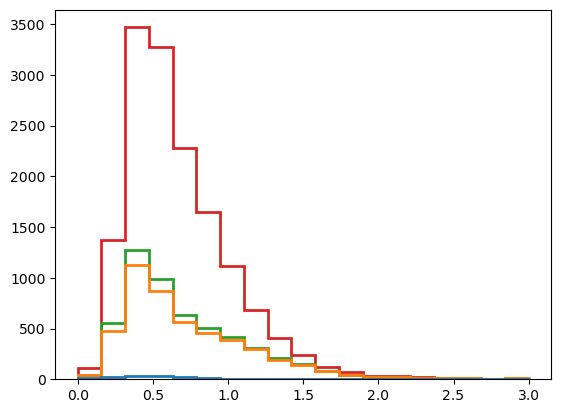

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the distribution of reconstructed neutrino energy (`reco_e`).
# We have to set the binning manually because sometimes a filler value is used
# that is a very large number. To get the total predicted number of events,
# we have to add all MC sets and the EXT data set.

bins = np.linspace(0, 3, 20)
background_keys = list(set(rundata.keys()) - set(["data", "lee"]))
print(background_keys)
plt.hist(
    [rundata[key]["RecoPN"] for key in background_keys],
    bins=bins,
    weights=[rundata[key]["weights"] for key in background_keys],
    histtype="step",
    lw=2,
    stacked=True,
    label=[key for key in background_keys],
)
# show data hist on top as points with error bars
data_bin_content, data_bin_edges = np.histogram(
    rundata["data"]["RecoPN"], bins=bins, weights=rundata["data"]["weights"]

)
data_bin_errors = np.sqrt(data_bin_content)
data_bin_centers = (data_bin_edges[:-1] + data_bin_edges[1:]) / 2
plt.errorbar(
    data_bin_centers,
    data_bin_content,
    yerr=data_bin_errors,
    fmt="o",
    label="data",
    color="black",
)
plt.legend()
plt.xlabel("Reconstructed neutrino energy [GeV]")
plt.ylabel("Events per bin")
plt.title("Reconstructed neutrino energy distribution")
plt.show()

## Load Signal: 1e1p

In [6]:
from microfit.histogram import Binning, Histogram, RunHistGenerator

# The query strings for the selection are defined in the `selections.py` file.
selection = "TKI_1e1p"
preselection = "NUE"
# Binnings are defined by the variable to be binned, the number of bins, and the range, and the label.
binning_def = ("RecoPN", 12, (0.0, 1.2), r"pN (GeV)")
binning = Binning.from_config(*binning_def)
binning.label = "TKI_1e1p"  # a unique label to identify the channel later
binning.set_selection(selection, preselection)
# The binning is a class with a defined repr:
binning

Binning(variable='RecoPN', bin_edges=array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2]), label='TKI_1e1p', variable_tex='pN (GeV)', variable_tex_short=None, is_log=False, selection_query='nslice == 1 and selected == 1 and shr_energy_tot_cali > 0.07 and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1) and nslice == 1 and selected == 1 and shr_energy_tot_cali > 0.07 and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1) and n_showers_contained > 0 and n_tracks_contained > 0 and CosmicIPAll3D > 10. and trkpid<(0.015*trk_len+0.02) and hits_ratio > 0.50 and shrmoliereavg < 9 and subcluster > 4 and trkfit < 0.65 and shr_trk_len < 300. and n_showers_contained == 1 and tksh_distance < 10.0 and tksh_angle > -0.9 and pi0_score > 0.50 and nonpi0_score > 0.50 and protonenergy_corr > 0.05 and n_tracks_contained == 1', selection_key='TKI_1e1p', preselection_key='NUE', selection_tex='1e1p Selection', selecti

In [7]:
signal_generator = RunHistGenerator(
    rundata,
    binning,
    data_pot=data_pot,
    # selection=selection,
    # preselection=preselection,
)

Histogram(binning=Binning(variable='RecoPN', bin_edges=array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2]), label='TKI_1e1p', variable_tex='pN (GeV)', variable_tex_short=None, is_log=False, selection_query=None, selection_key='TKI_1e1p', preselection_key='NUE', selection_tex='1e1p Selection', selection_tex_short='1e1p Selection'), bin_counts=[1.13526029 4.35743614 5.34452682 3.81617413 2.75539513 1.48857223
 0.9890581  2.18540952 0.26172013 0.13384095 0.05512871 0.03972387], label=MC+EXT, tex=MC+EXT)

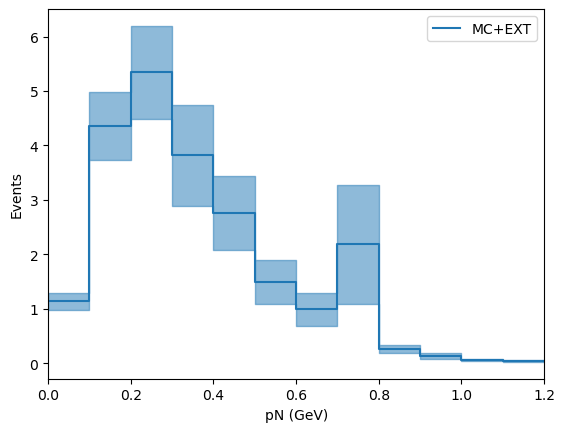

In [8]:
total_prediction = signal_generator.get_total_prediction(include_multisim_errors=True)
# The `Histogram` class also defines a repr that makes a nice plot when run inside a Jupyter notebook:
total_prediction

In [9]:
from microfit.signal_generators import SignalOverBackgroundGenerator
from microfit.parameters import Parameter, ParameterSet
from microfit.run_plotter import RunHistPlotter


signal_parameters = ParameterSet(
    [
        Parameter("signal_strength", 1.0, bounds=(0, 10)),
    ]
)

signal_generator = RunHistGenerator(
    rundata,
    binning,
    data_pot=data_pot,
    # selection=selection,
    # preselection=preselection,
    # This overrides the default `HistogramGenerator` class, which just produces 
    # a histogram without any parametrization.
    mc_hist_generator_cls=SignalOverBackgroundGenerator,
    parameters=signal_parameters,
    signal_query="category == 12", # 1e1p in data_loading.py
    background_query="category != 12",
)
signal_plotter = RunHistPlotter(signal_generator)

../../microfit/run_plotter.py:132: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


(<AxesSubplot:xlabel='pN (GeV)', ylabel='Events'>, None)

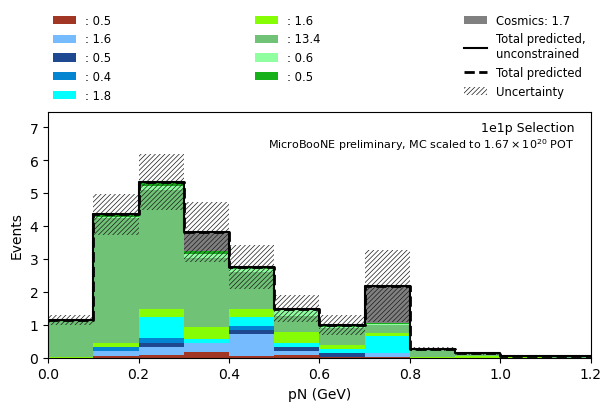

In [10]:
# The ParameterSet defines a set of parameters that may be used by several signal generators at once. 
signal_plotter.plot(include_multisim_errors=True, add_ext_error_floor=False, category_column="category_1e1p", scale_to_pot=data_pot)

## Loading Sideband: 1mu1p

In [11]:
blinded = True
#For 1mu1p
RUN = ["3"]
rundata_mu, mc_weights_mu, data_pot_mu = load_runs(
    RUN,
    data="opendata_bnb",  # which data to load opendata for now
    truth_filtered_sets=["nue", "drt"],
    loadpi0variables=True,
    loadshowervariables=True,
    loadrecoveryvars=True,
    loadsystematics=True,
    loadnumuvariables=True, # True for 1mu1p/ False for 1e1p
    numupresel=False, # Set to False for full sample
    load_lee=False,
    enable_cache=True,
    # Since this is Open Data, we are allowed to unblind the data. By default, the data is blinded.
    blinded=blinded,
    load_numu_tki=True,
    load_nue_tki=True
)


Loading run 3


In [12]:
from microfit.run_plotter import RunHistPlotter

# note that the sideband is binned by a different variable
sideband_binning = Binning.from_config("RecoPN_1mu1p", 12, (0.0, 1.2), "1mu1p pN (GeV)")
sideband_binning.label = "TKI_1mu1p"  # a unique label to identify the channel later
sideband_generator = RunHistGenerator(
    rundata_mu,
    sideband_binning,
    data_pot=data_pot_mu,
    selection="TKI_1mu1p",
    preselection="NUMU",
)
sideband_plotter = RunHistPlotter(sideband_generator)

(<AxesSubplot:xlabel='1mu1p pN (GeV)', ylabel='Events'>, None)

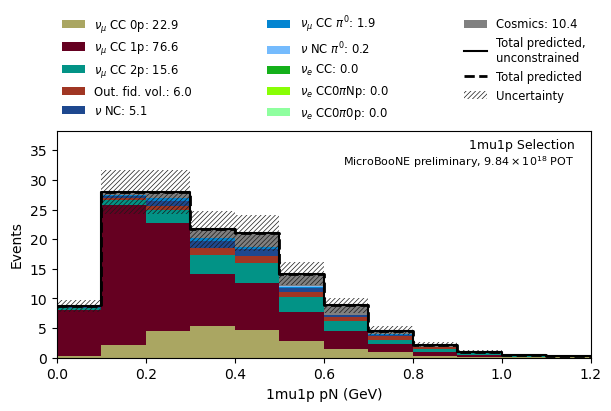

In [13]:
sideband_plotter.plot(
    include_multisim_errors=True,
    add_ext_error_floor=False,
    category_column="category_1mu1p",
    show_chi_square=False,
)

## Constraint

In [14]:
from microfit.analysis import MultibandAnalysis

# At this point, the "label" properties that we have assigend to the binnings are used to
# identify the channels. The analysis generates a multi-channel histogram with the
# appropriate correlations between bins. Then, sideband constraints can be applied to
# the signal channels.
analysis = MultibandAnalysis(run_hist_generators=[sideband_generator, signal_generator], constraint_channels=["TKI_1mu1p"], signal_channels=["TKI_1e1p"])

In [15]:
analysis.channels

['TKI_1mu1p', 'TKI_1e1p']

In [16]:
analysis.signal_channels

['TKI_1e1p']

<AxesSubplot:xlabel='Global bin number', ylabel='Events'>

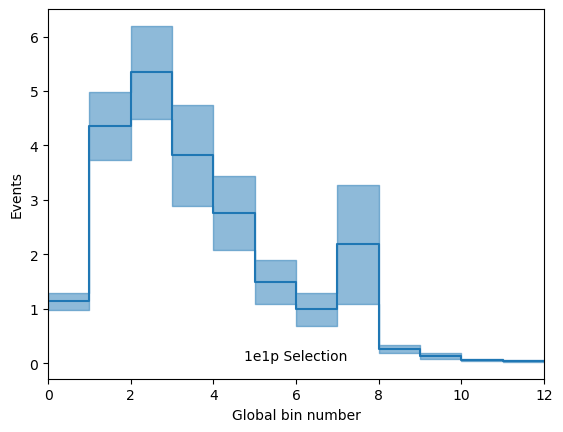

In [17]:
histogram_no_constraint = analysis.generate_multiband_histogram(
    include_multisim_errors=True
)
histogram_with_constraint = analysis.generate_multiband_histogram(
    include_multisim_errors=True, use_sideband=True
)

# This is a multi-channel histogram of the MC prediction *before* the application of the sideband constraint
#histogram_with_constraint.draw()
histogram_no_constraint.draw()

<AxesSubplot:title={'center':'Correlation matrix'}>

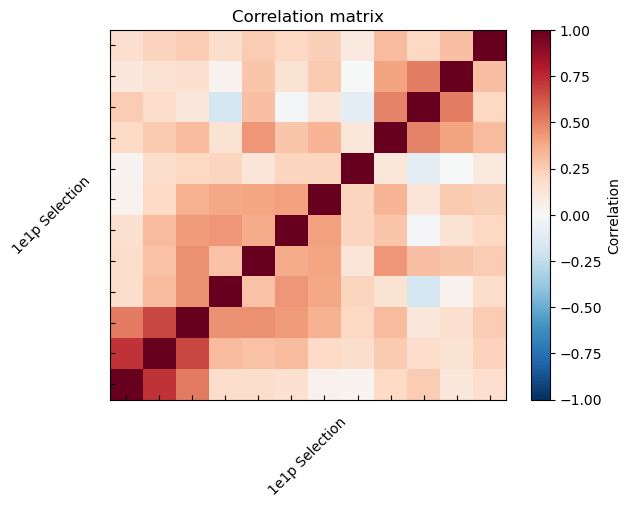

In [18]:
# The histogram contains the full covariance matrix between all channels.
histogram_no_constraint.draw_covariance_matrix()

<AxesSubplot:xlabel='pN (GeV)', ylabel='Events'>

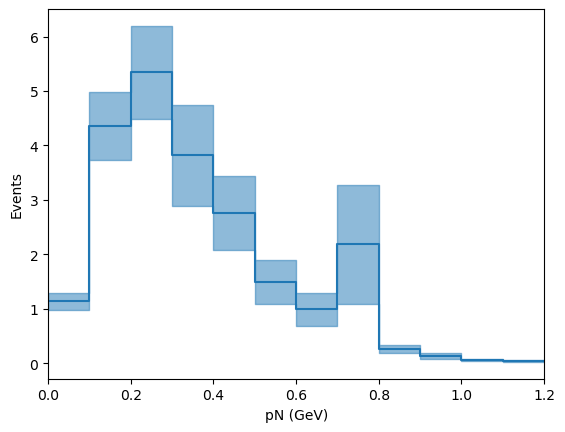

In [19]:
# We can extract channels from the multi-channel histogram by indices or by label.
histogram_no_constraint["TKI_1e1p"].draw()

<AxesSubplot:title={'center':'Correlation matrix'}, xlabel='pN (GeV)', ylabel='pN (GeV)'>

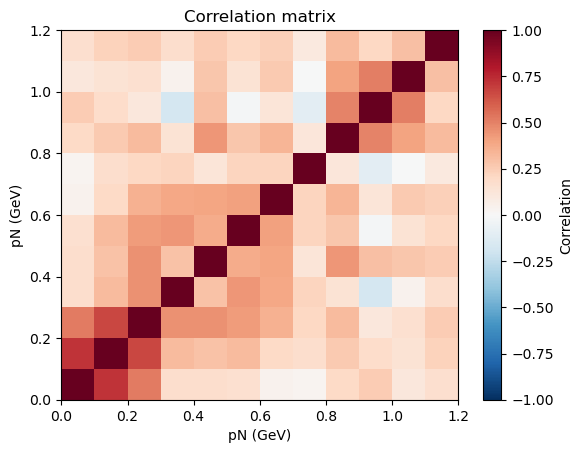

In [20]:
# We can extract channels from the multi-channel histogram by indices or by label.
histogram_with_constraint["TKI_1e1p"].draw_covariance_matrix()

<AxesSubplot:title={'center':'Correlation matrix'}>

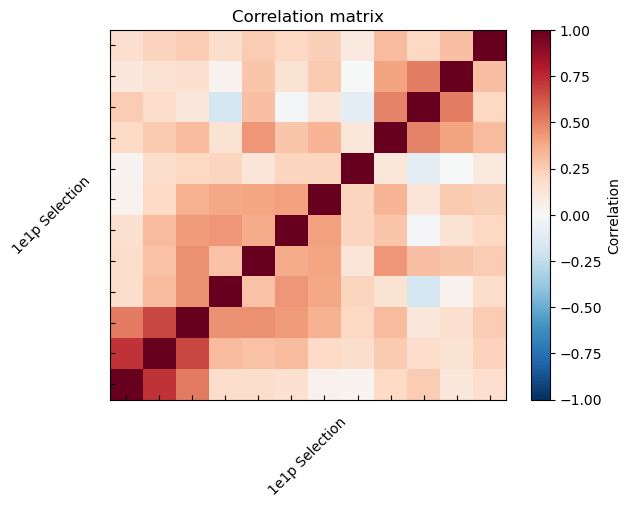

In [21]:
# Passing more than one key will extract the multi-channel histogram for the given channels.
histogram_with_constraint[["TKI_1e1p"]].draw_covariance_matrix()

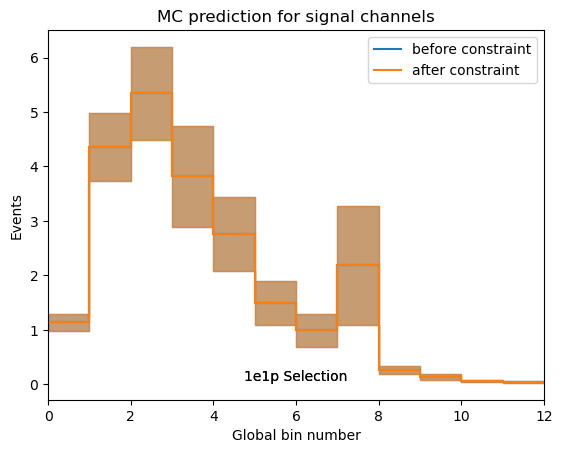

In [22]:
# Let's compare the signal histograms before and after the sideband constraint.
fig, ax = plt.subplots()
histogram_no_constraint[["TKI_1e1p"]].draw(ax=ax, label="before constraint", as_errorbars=False)
histogram_with_constraint[["TKI_1e1p"]].draw(ax=ax, label="after constraint", as_errorbars=False)
ax.legend()
ax.set_title("MC prediction for signal channels")
plt.show()

## Correlation

plotting channel: TKI_1e1p


../../microfit/run_plotter.py:132: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


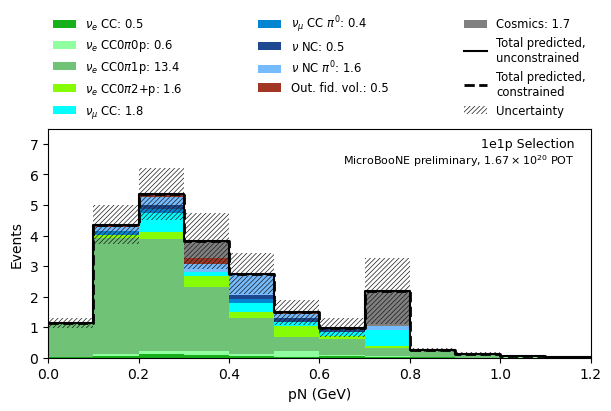

In [23]:
analysis.plot_signals(
    add_ext_error_floor=False, 
    include_multisim_errors=True, 
    category_column="category_1e1p", 
    show_data_mc_ratio=False, 
    use_sideband=True,
    add_precomputed_detsys=False,
    separate_figures=True,
)

plotting channel: TKI_1mu1p


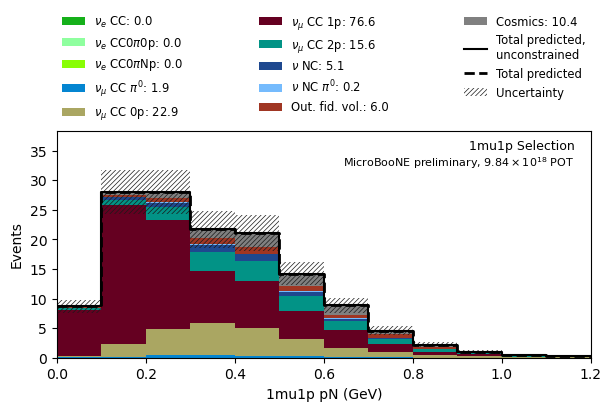

In [24]:
analysis.plot_sidebands(
    include_multisim_errors=True,
    show_data_mc_ratio=False,
    category_column="category_1mu1p",
    add_ext_error_floor=False,
    separate_figures=True,
    add_precomputed_detsys=True,
    save_path="."
)

(<Figure size 1000x800 with 2 Axes>,
 <AxesSubplot:title={'center':'Correlation matrix'}>)

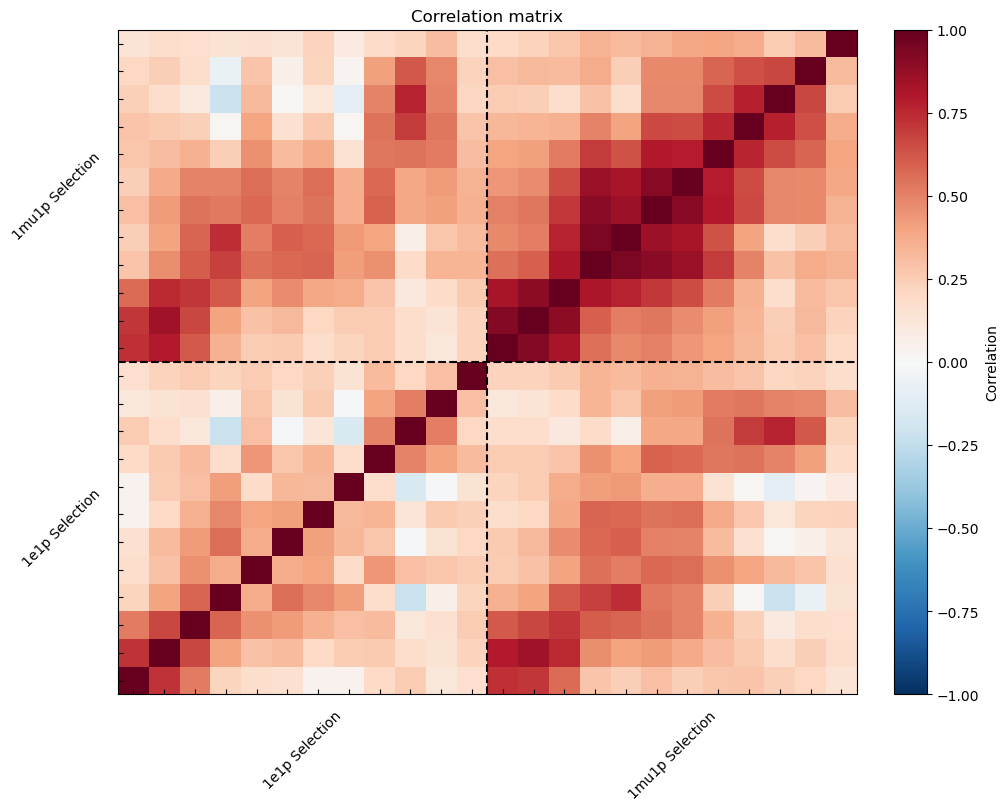

In [25]:
analysis.plot_correlation(add_precomputed_detsys=False)

In [26]:
analysis.channels

['TKI_1mu1p', 'TKI_1e1p']

## GENIE - ERROR

In [67]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../../")

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import selections

from microfit import detsys
from microfit import xsec_covariances as xs
from microfit.xsec_signal_generator import XsecCovarHistGenerator

In [68]:
from microfit.analysis import MultibandAnalysis

analysis_genie = MultibandAnalysis(run_hist_generators=[sideband_generator, signal_generator], constraint_channels=["TKI_1mu1p"], signal_channels=["TKI_1e1p"])

In [93]:
print(rundata.keys())
print(mc_weights.keys())

dict_keys(['data', 'ext', 'mc', 'nue', 'drt'])
dict_keys(['data', 'ext', 'mc', 'nue', 'drt'])


In [109]:
# # Prune to GENIE only (safe version that skips NONE entries) 
# import copy

# def _prune_df_to_genie(df):
#     try:
#         cols = list(df.columns)
#     except Exception:
#         return df
#     drop = [c for c in cols if c.startswith("weights") and c != "weightsGenie"]
#     return df.drop(columns=drop, errors="ignore")

# def _prune_obj_to_genie(obj):
#     if obj is None:
#         return None
#     if isinstance(obj, dict):
#         return {k: _prune_obj_to_genie(v) for k, v in obj.items()}
#     if hasattr(obj, "columns"):
#         return _prune_df_to_genie(obj)
#     return obj

# def restrict_multisim_to_genie_safe(rundata, mc_weights):
#     rd = copy.deepcopy(rundata)
#     mw = copy.deepcopy(mc_weights)

#     rd = _prune_obj_to_genie(rd)

#     if isinstance(mw, dict):
#         def _filter(d):
#             if not isinstance(d, dict): return d
#             out = {}
#             for k, v in d.items():
#                 out[k] = {kk: vv for kk, vv in v.items()} if isinstance(v, dict) else v
#                 if isinstance(out[k], dict):
#                     out[k] = {kk: vv for kk, vv in out[k].items() if kk == "weightsGenie"}
#             return out
#         mw = _filter(mw)
#     return rd, mw

# # backup, assign, plot, restore 
# rd_backup = getattr(analysis_genie, "rundata", None)
# mw_backup = getattr(analysis_genie, "mc_weights", None)

# rundata_genie, mc_weights_genie = restrict_multisim_to_genie_safe(rd_backup, mw_backup)
# setattr(analysis_genie, "rundata", rundata_genie)
# setattr(analysis_genie, "mc_weights", mc_weights_genie)


# # # restore originals (For full systemtics)
# # setattr(analysis_genie, "rundata", rd_backup)
# # setattr(analysis_genie, "mc_weights", mw_backup)
import copy

MC_SAMPLES = {"mc", "nue", "drt"}  # only prune these

def _prune_df_to_genie(df):
    try:
        cols = list(df.columns)
    except Exception:
        return df
    drop = [c for c in cols if c.startswith("weights") and c != "weightsGenie"]
    return df.drop(columns=drop, errors="ignore")

def _prune_rundata_flat(rd):
    if not isinstance(rd, dict):
        return rd
    out = {}
    for k, v in rd.items():
        if k in MC_SAMPLES and hasattr(v, "columns"):
            out[k] = _prune_df_to_genie(v)
        elif isinstance(v, dict):  # nested dicts (rare in your case)
            out[k] = _prune_rundata_flat(v)
        else:
            out[k] = v
    return out

def _filter_mc_weights(mw):
    # keep only 'weightsGenie' anywhere inside dicts
    if not isinstance(mw, dict):
        return mw
    out = {}
    for k, v in mw.items():
        if isinstance(v, dict):
            # strip to GENIE at this level
            out[k] = {kk: vv for kk, vv in v.items() if kk == "weightsGenie"}
            # and recurse just in case of deeper nesting
            out[k] = _filter_mc_weights(out[k])
        else:
            out[k] = v
    return out

def restrict_multisim_to_genie_safe(rundata, mc_weights):
    rd = copy.deepcopy(rundata)
    mw = copy.deepcopy(mc_weights)
    rd = _prune_rundata_flat(rd)
    mw = _filter_mc_weights(mw)
    return rd, mw

# ---- apply on your object ----
rd_backup = getattr(analysis_genie, "rundata", None)
mw_backup = getattr(analysis_genie, "mc_weights", None)

rundata_genie, mc_weights_genie = restrict_multisim_to_genie_safe(rd_backup, mw_backup)
setattr(analysis_genie, "rundata", rundata_genie)
setattr(analysis_genie, "mc_weights", mc_weights_genie)


In [117]:
print(rundata["mc":w])
print(rundata_genie)

           tksh_angle  secondshower_U_vtxdist  \
entry                                           
0       -3.402823e+38            3.402823e+38   
1       -3.402823e+38            3.402823e+38   
2       -3.402823e+38            3.402823e+38   
3       -3.402823e+38            1.040928e+02   
4       -3.402823e+38            4.082329e+01   
...               ...                     ...   
1025780 -3.402823e+38            1.049396e+02   
1025781 -3.402823e+38            1.642841e+02   
1025782 -3.402823e+38            3.402823e+38   
1025783 -3.402823e+38            2.174007e+02   
1025784 -3.402823e+38            1.042570e+02   

                                              weightsReint  mcf_pass_ncnopi  \
entry                                                                         
0        [995, 986, 1007, 1000, 993, 997, 996, 996, 100...                0   
1        [998, 995, 1002, 1000, 997, 999, 998, 998, 100...                0   
2        [991, 974, 1014, 1001, 986, 995, 993,

<AxesSubplot:xlabel='Global bin number', ylabel='Events'>

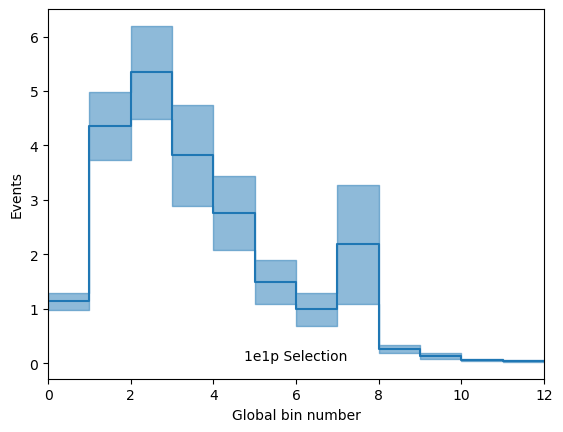

In [97]:
histogram_no_constraint = analysis_genie.generate_multiband_histogram(
    include_multisim_errors=True
)
histogram_with_constraint = analysis_genie.generate_multiband_histogram(
    include_multisim_errors=True, use_sideband=True
)

# This is a multi-channel histogram of the MC prediction *before* the application of the sideband constraint
#histogram_with_constraint.draw()
histogram_no_constraint.draw()

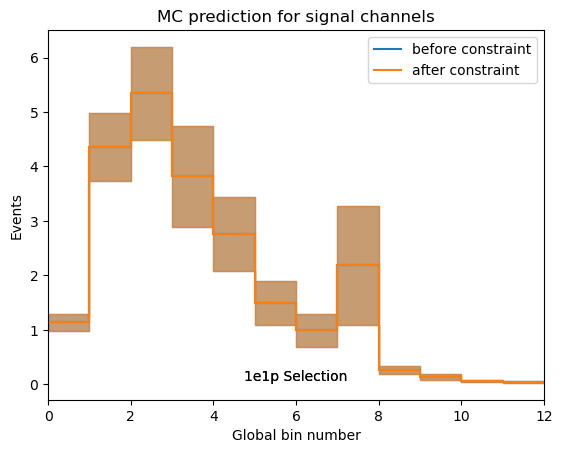

In [98]:
fig, ax = plt.subplots()
histogram_no_constraint[["TKI_1e1p"]].draw(ax=ax, label="before constraint", as_errorbars=False)
histogram_with_constraint[["TKI_1e1p"]].draw(ax=ax, label="after constraint", as_errorbars=False)
ax.legend()
ax.set_title("MC prediction for signal channels")
plt.show()

plotting channel: TKI_1e1p


../../microfit/run_plotter.py:132: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


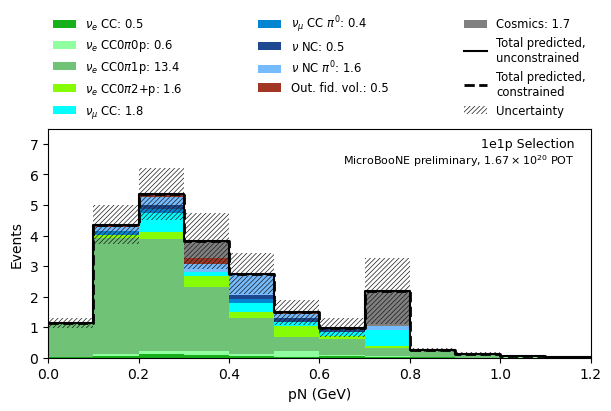

In [99]:
analysis_genie.plot_signals(
    add_ext_error_floor=False,
    include_multisim_errors=True,   # now it only sees weightsGenie
    category_column="category_1e1p",
    show_data_mc_ratio=False,
    use_sideband=True,
    add_precomputed_detsys=False,
    separate_figures=True,
)


plotting channel: TKI_1mu1p


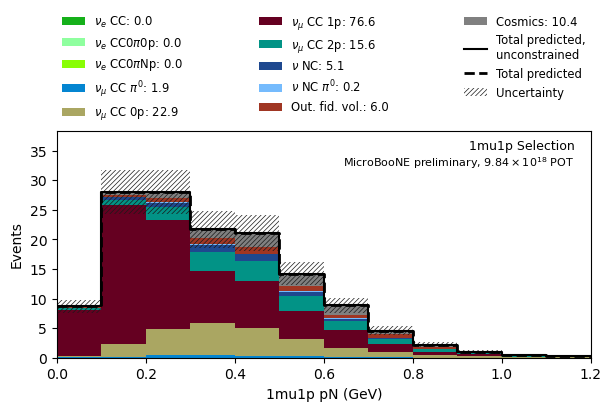

In [100]:
analysis_genie.plot_sidebands(
    include_multisim_errors=True,
    show_data_mc_ratio=False,
    category_column="category_1mu1p",
    add_ext_error_floor=False,
    separate_figures=True,
    add_precomputed_detsys=True,
    save_path="."
)

(<Figure size 1000x800 with 2 Axes>,
 <AxesSubplot:title={'center':'Correlation matrix'}>)

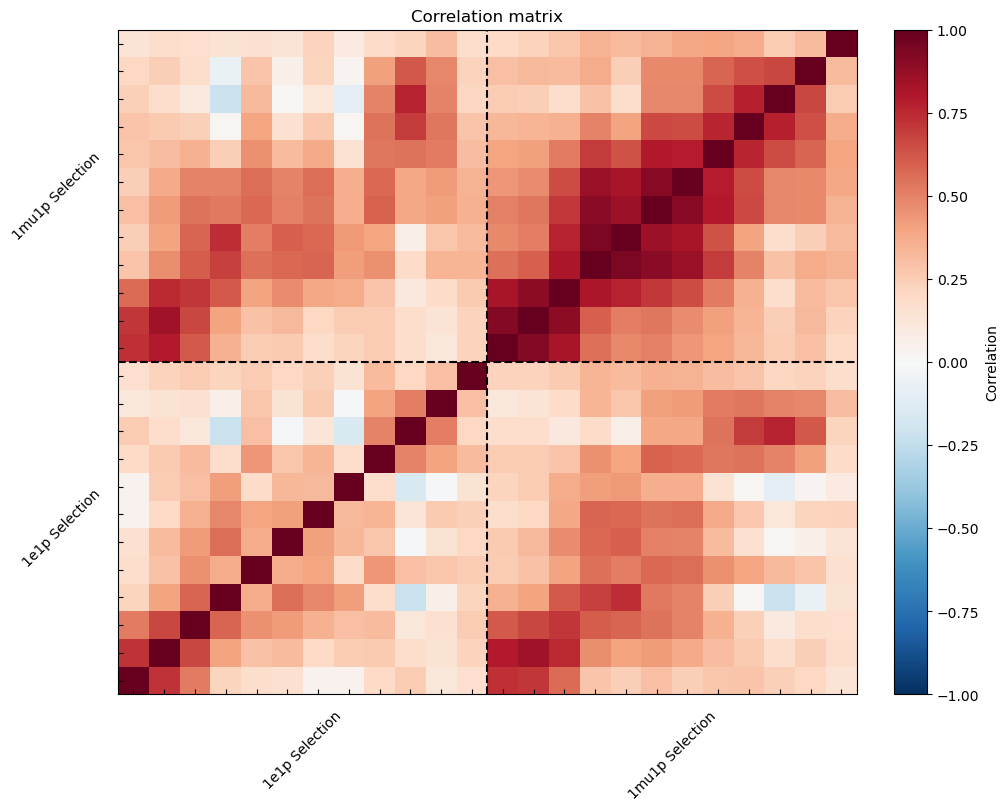

In [101]:
analysis_genie.plot_correlation(add_precomputed_detsys=False)